In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# データを読み込み、すべての列を数値型に変換
data = pd.read_csv("C_labeled.csv")

a=len(data)
print(a)

114499


Text(0, 0.5, 'counts')

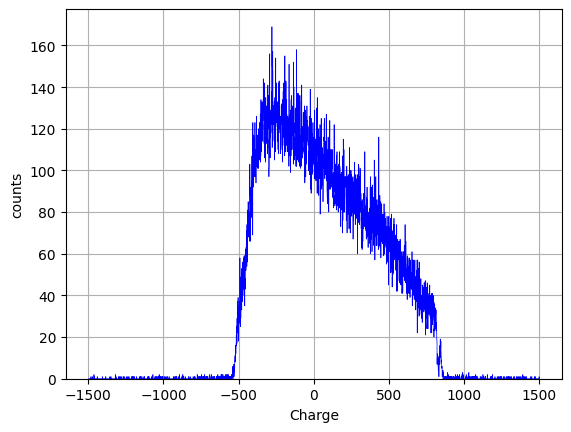

In [22]:
xdp=data['GRX']
adp=data['GRA']
ydp=data['GRY']
bdp=data['GRB']
GRQ2=data['GRQ2charge']

lx=data['LASX']

import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=lx
#hist range
range_min=0-1500
range_max=1500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('Charge')
ax.set_ylabel('counts')

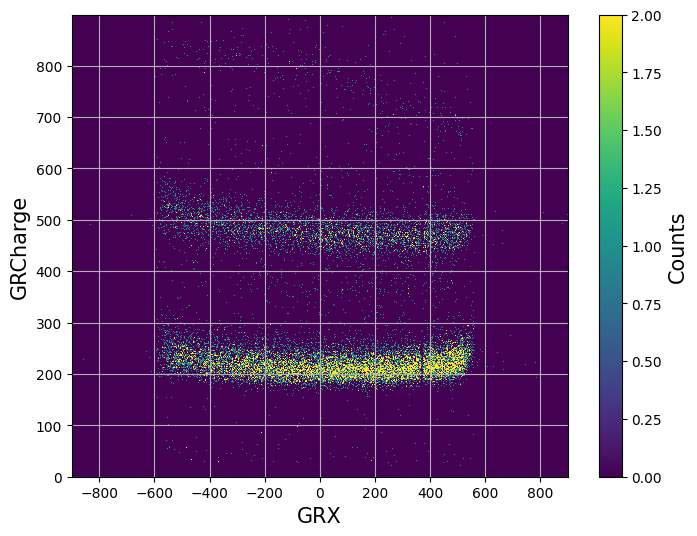

In [23]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=xdp
y_axis_variable=GRQ2
#hist range
x_axis_range_min=-900
x_axis_range_max=900
y_axis_range_min=0
y_axis_range_max=900
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 4)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts', fontsize = 15)

# 軸範囲とグリッド
ax.set_xlabel(r'GRX', fontsize = 15)
ax.set_ylabel(r'GRCharge', fontsize = 15)
ax.grid()

plt.show()

Text(0, 0.5, 'counts')

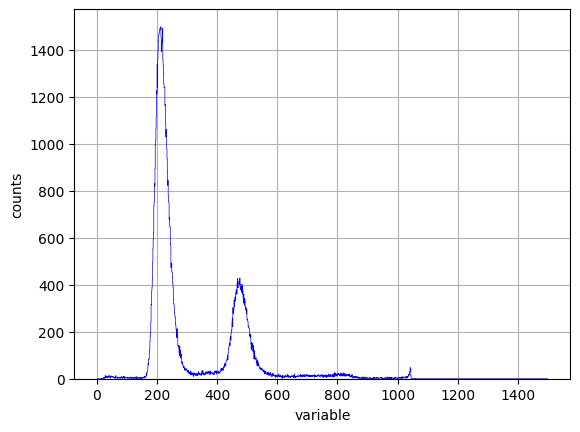

In [24]:
#トラッキングできたのを抽出

tracking_gated=data[
    (xdp!=-9999) & (ydp!=-9999)
]

xdp_track=tracking_gated['GRX']
adp_track=tracking_gated['GRA']
ydp_track=tracking_gated['GRY']
bdp_track=tracking_gated['GRB']
GRQ2_track=tracking_gated['GRQ2charge']

import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=GRQ2_track
#hist range
range_min=0
range_max=1500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 1477.857 ± 10.997
Mean: 212.271 ± 0.260
Sigma: 21.398 ± 0.494


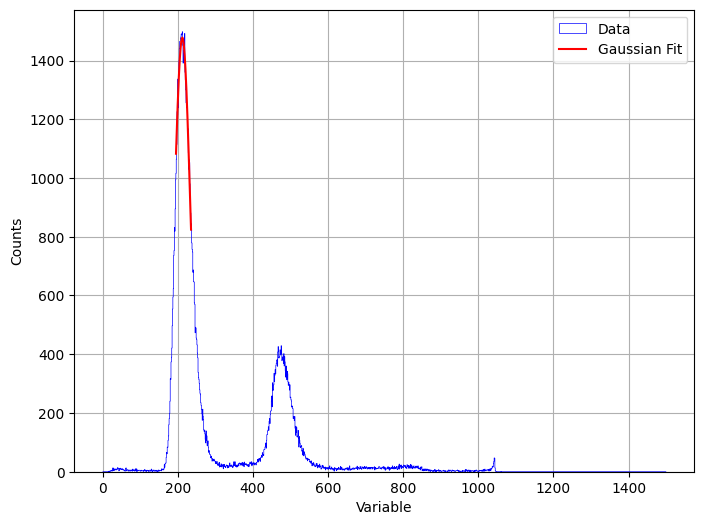

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Input
##############################################################
# Fitする変数
fit_variable = GRQ2_track
# Histogram range
hist_range_min = 0
hist_range_max = 1500
# Bin width
bin_width = 1
# Fit range
fit_range_min = 215.391-20
fit_range_max = 215.391+20
# Initial parameters for the Gaussian
Amp = 17500
mean = 215.391
sigma = 5
# Fit parameter boundaries
bound_min = [0, -100, 0]
bound_max = [np.inf, 300, 50]
##############################################################

# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(fit_variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(fit_range_min, fit_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(fit_variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

plt.show()

Text(0, 0.5, 'counts')

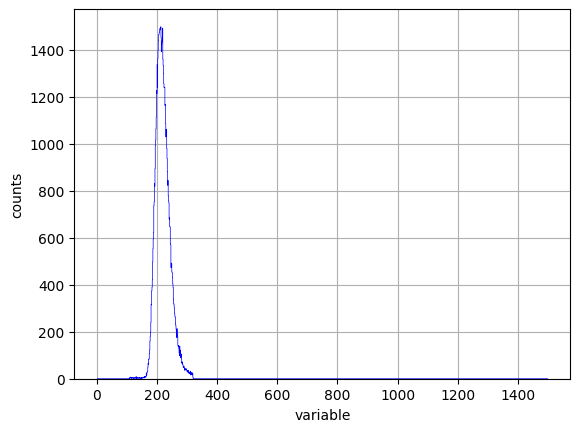

In [26]:
#プロトンゲート設定
proton_gated=tracking_gated[
    (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5)
]

xdp_proton=proton_gated['GRX']
adp_proton=proton_gated['GRA']
ydp_proton=proton_gated['GRY']
bdp_proton=proton_gated['GRB']
GRQ2_proton=proton_gated['GRQ2charge']

import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=GRQ2_proton
#hist range
range_min=0
range_max=1500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')